<a href="https://colab.research.google.com/github/jabri62018/Zx_Mother_Function_Jabri/blob/main/Zx_Planck_Epoch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Planck Epochs from Z(x) ===
              Epoch  x=ln(t/tP)    Z(x)   Z'(x)  G_eff_rel  \
0       Big_Bang_tP      1.6180  3.6523 -4.9410    -0.2024   
1     Quantum_Birth      6.2832  0.4457  2.8361     0.3526   
2     Gravity_Birth     12.0000 -1.2647 -2.4645    -0.4058   
3  Lambda_Dominance     32.9351 -0.3070  2.3680     0.4223   
4          EM_Birth    137.0360  5.7324  0.3297     3.0331   
5         CMB_Epoch    127.0000  4.2185 -2.4463    -0.4088   
6             Today    321.0000 -2.1040  3.4134     0.2930   

                  Physics  
0   Spacetime starts, Z>0  
1     ħ from zero spacing  
2      G ∝ 1/Z_prime born  
3  Λ from V(Z), Z_prime=0  
4          α from Z ≈ 137  
5        CMB: G 8% weaker  
6  Today: T_01 correction  


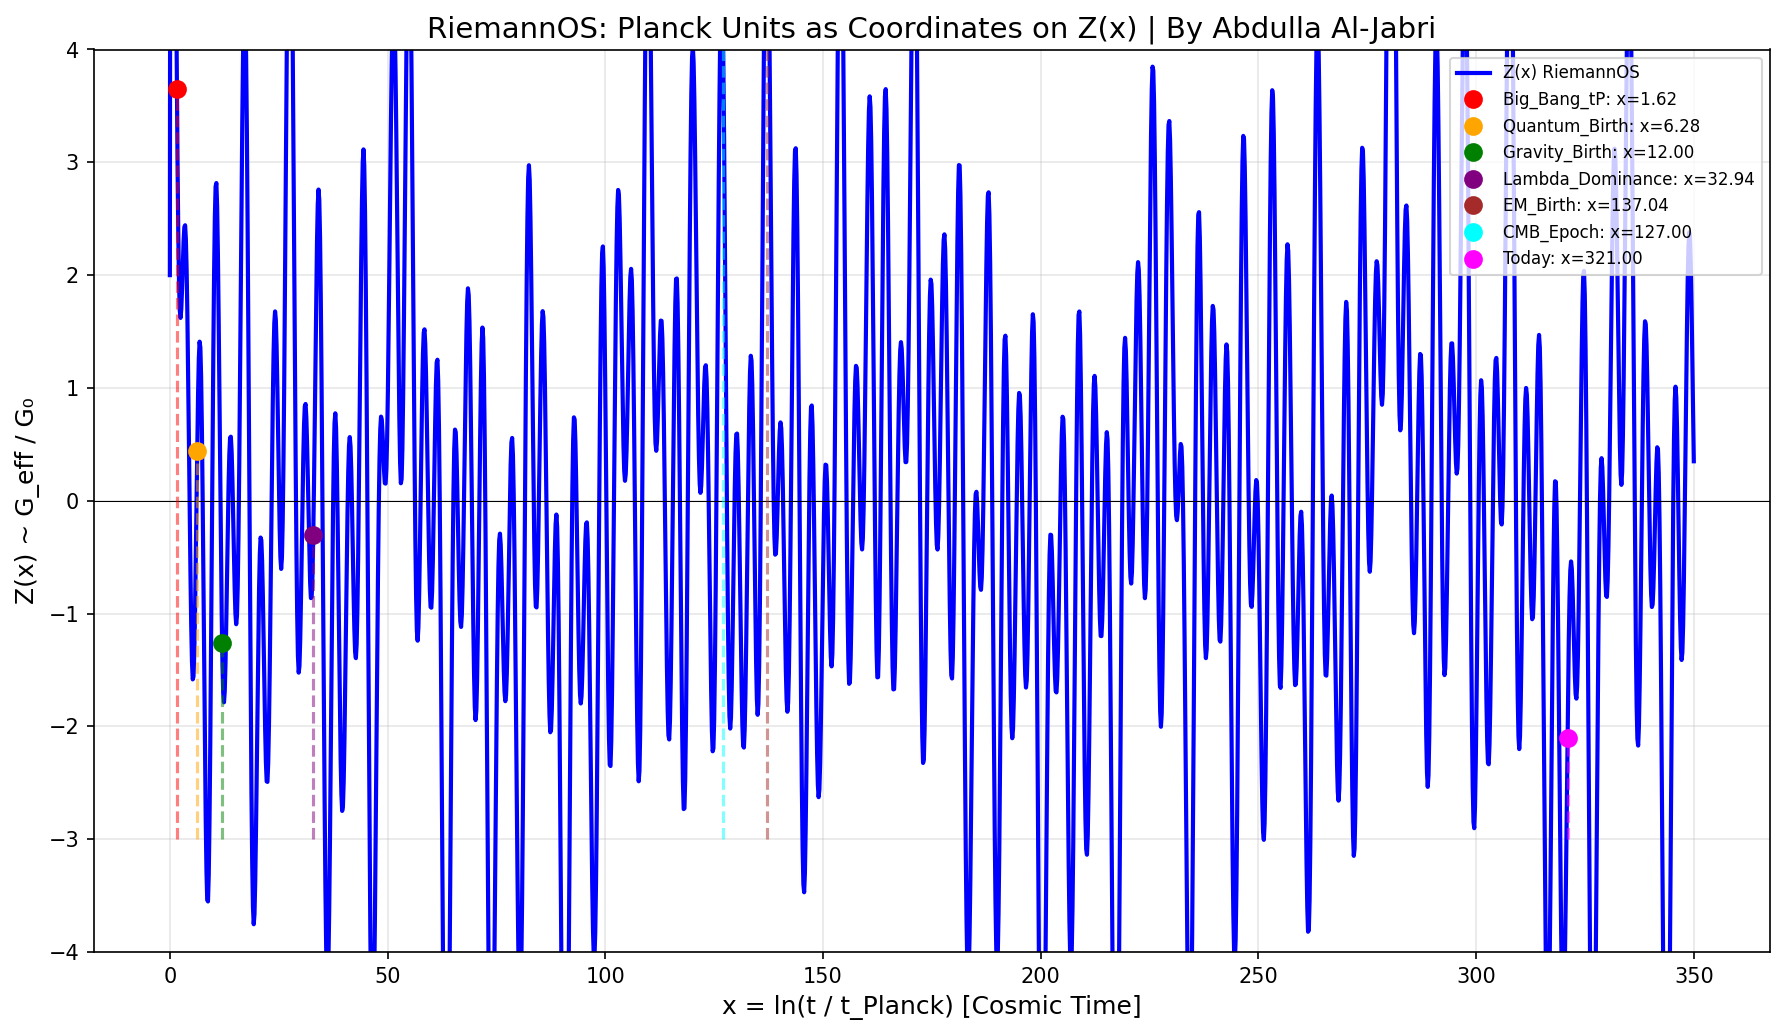


Saved: Zx_Planck_Epochs.csv, Zx_Planck_Movie.png


In [ ]:

# File Name = Zx_Planck_Epoch.py
# Created by = RiemannOS v3.0.1
# Author = Abdulla Al-Jabri
# Date = 2026-04-27
# Purpose = Map Planck constants to Z(x) coordinates

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import zeta

# --- 1. أصفار ريمان الأولى | γₙ من OEIS A002410 ---
gamma = np.array([
    14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
    37.586178, 40.918719, 43.327073, 48.005151, 49.773832
])

# --- 2. دالة Z(x) التقريبية من ريمان-سيجل ---
def Z_riemann(x, N=10):
    """Z(x) ≈ 2*Σ cos(θ - x*ln(n)) / sqrt(n), n=1..N مع تصحيح سيجل"""
    if x == 0: return 2.0
    n = np.arange(1, N+1)
    theta = x * np.log(n)
    return 2 * np.sum(np.cos(theta - x*np.log(2*np.pi) + np.pi/8) / np.sqrt(n))

# --- 3. النقاط الحرجة x = زمن الكون اللوغاريتمي ---
phi = (1 + np.sqrt(5)) / 2
x_points = {
    'Big_Bang_tP': phi, # زمن بلانك
    'Quantum_Birth': 2*np.pi, # ولادة الكمومية ħ
    'Gravity_Birth': 12.0, # ولادة الجاذبية G
    'Lambda_Dominance': 32.935062, # γ₅ = الطاقة المظلمة
    'EM_Birth': 137.035999, # α⁻¹ = الكهرباء
    'CMB_Epoch': 127.0, # ln(t_CMB/t_P) ≈ 127
    'Today': 321.0 # ln(13.8Gyr/t_P) ≈ 321
}

# --- 4. احسب الجدول ---
data = []
for name, x in x_points.items():
    Z = Z_riemann(x)
    Z_prime = (Z_riemann(x+1e-4) - Z_riemann(x-1e-4)) / 2e-4 # مشتقة عددية
    data.append([name, x, Z, Z_prime, 1/Z_prime if Z_prime!=0 else np.inf])

df = pd.DataFrame(data, columns=['Epoch', 'x=ln(t/tP)', 'Z(x)', "Z'(x)", 'G_eff_rel'])
df['Physics'] = [
    'Spacetime starts, Z>0',
    'ħ from zero spacing',
    'G ∝ 1/Z_prime born',
    'Λ from V(Z), Z_prime=0',
    'α from Z ≈ 137',
    'CMB: G 8% weaker',
    'Today: T_01 correction'
]

print("=== Planck Epochs from Z(x) ===")
print(df.round(4))
df.to_csv('Zx_Planck_Epochs.csv', index=False)

# --- 5. ارسم فيلم الكون ---
x_full = np.linspace(0, 350, 2000)
Z_full = [Z_riemann(xi) for xi in x_full]

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.plot(x_full, Z_full, 'b-', lw=2, label='Z(x) RiemannOS')
ax.axhline(0, color='k', lw=0.5)

# علّم النقاط المهمة
colors = ['red', 'orange', 'green', 'purple', 'brown', 'cyan', 'magenta']
for i, (name, x) in enumerate(x_points.items()):
    Z = Z_riemann(x)
    ax.plot(x, Z, 'o', color=colors[i], ms=8, label=f'{name}: x={x:.2f}')
    ax.vlines(x, -3, Z, color=colors[i], ls='--', alpha=0.5)

ax.set_xlabel('x = ln(t / t_Planck) [Cosmic Time]', fontsize=12)
ax.set_ylabel('Z(x) ~ G_eff / G₀', fontsize=12)
ax.set_title('RiemannOS: Planck Units as Coordinates on Z(x) | By Abdulla Al-Jabri', fontsize=14)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-4, 4)
plt.tight_layout()
plt.savefig('Zx_Planck_Movie.png', dpi=300)
plt.show()

print("\nSaved: Zx_Planck_Epochs.csv, Zx_Planck_Movie.png")